In [21]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from imblearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier

import pickle

ModuleNotFoundError: No module named 'numpy'

In [ ]:
import pickle

with open("backend/model/autism_model.pkl", "wb") as f:
    pickle.dump(voting_model, f)

print("Model saved successfully")

NameError: name 'voting_model' is not defined

In [ ]:
import pickle

with open("backend/model/autism_model.pkl", "wb") as f:
    pickle.dump(voting_model, f)

print("Model saved successfully")

NameError: name 'voting_model' is not defined

: 

In [ ]:
# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv("C:\Users\asus\Downloads\Aurtism")

print(df.shape)

print(df.head())

print(df.info())

print(df.describe())

(2000, 16)
   age  jaundice  austim  gender  A1_Score  A2_Score  A3_Score  A4_Score  \
0   43         1       1       1         0         0         1         1   
1   56         1       0       0         0         1         1         1   
2   33         0       0       0         0         0         1         1   
3   19         1       1       0         1         1         0         1   
4   47         0       1       0         0         0         1         1   

   A5_Score  A6_Score  A7_Score  A8_Score  A9_Score  A10_Score  total_score  \
0         0         0         0         0         1          0            3   
1         0         0         1         1         0          0            5   
2         0         1         0         1         0          0            4   
3         0         1         1         0         0          0            5   
4         1         0         1         0         0          0            4   

   Class/ASD  
0          1  
1          0  
2          0

In [ ]:
# =========================================================
# CHECK NULL VALUES
# =========================================================

print(df.isnull().sum())

# =========================================================
# CHECK DUPLICATES
# =========================================================

print(df.duplicated().sum())

# =========================================================
# DATA TYPES
# =========================================================

print(df.dtypes)

age            0
jaundice       0
austim         0
gender         0
A1_Score       0
A2_Score       0
A3_Score       0
A4_Score       0
A5_Score       0
A6_Score       0
A7_Score       0
A8_Score       0
A9_Score       0
A10_Score      0
total_score    0
Class/ASD      0
dtype: int64
9
age            int64
jaundice       int64
austim         int64
gender         int64
A1_Score       int64
A2_Score       int64
A3_Score       int64
A4_Score       int64
A5_Score       int64
A6_Score       int64
A7_Score       int64
A8_Score       int64
A9_Score       int64
A10_Score      int64
total_score    int64
Class/ASD      int64
dtype: object


In [ ]:
# =========================================================
# FEATURE ENGINEERING
# =========================================================

df['total_score'] = df[
    [f"A{i}_Score" for i in range(1, 11)]
].sum(axis=1)

print(df.head())

   age  jaundice  austim  gender  A1_Score  A2_Score  A3_Score  A4_Score  \
0   43         1       1       1         0         0         1         1   
1   56         1       0       0         0         1         1         1   
2   33         0       0       0         0         0         1         1   
3   19         1       1       0         1         1         0         1   
4   47         0       1       0         0         0         1         1   

   A5_Score  A6_Score  A7_Score  A8_Score  A9_Score  A10_Score  total_score  \
0         0         0         0         0         1          0            3   
1         0         0         1         1         0          0            5   
2         0         1         0         1         0          0            4   
3         0         1         1         0         0          0            5   
4         1         0         1         0         0          0            4   

   Class/ASD  
0          1  
1          0  
2          0  
3       

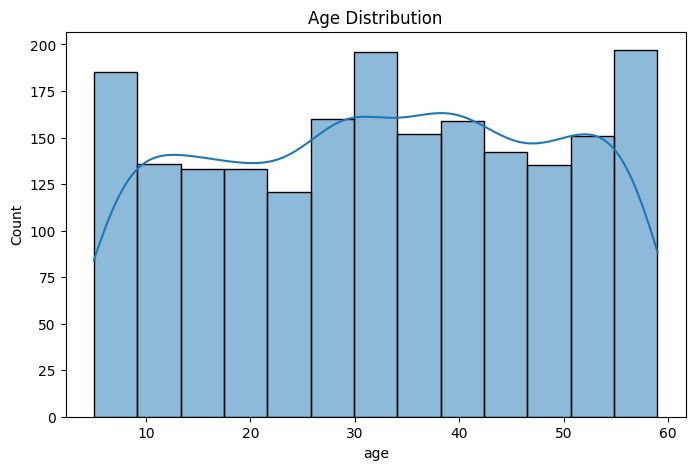

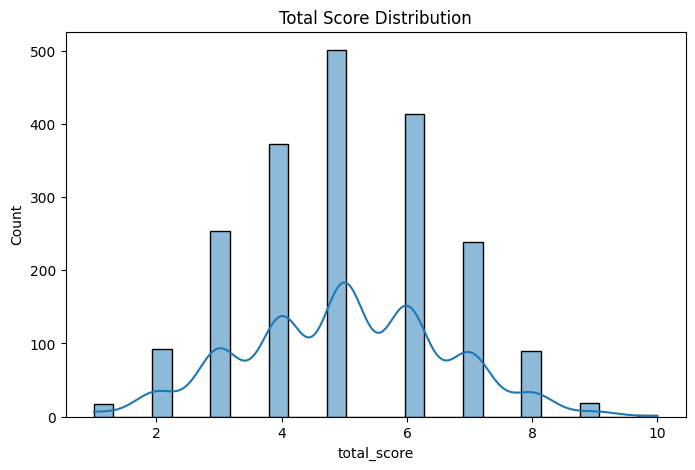

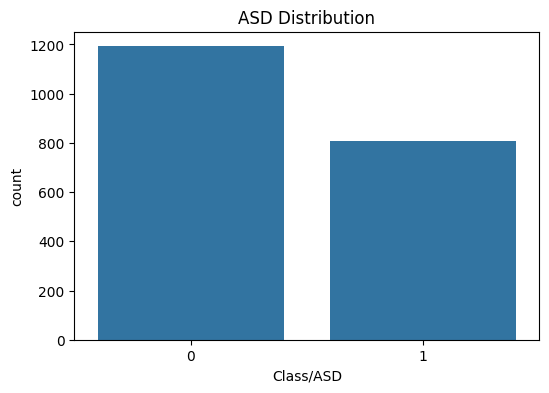

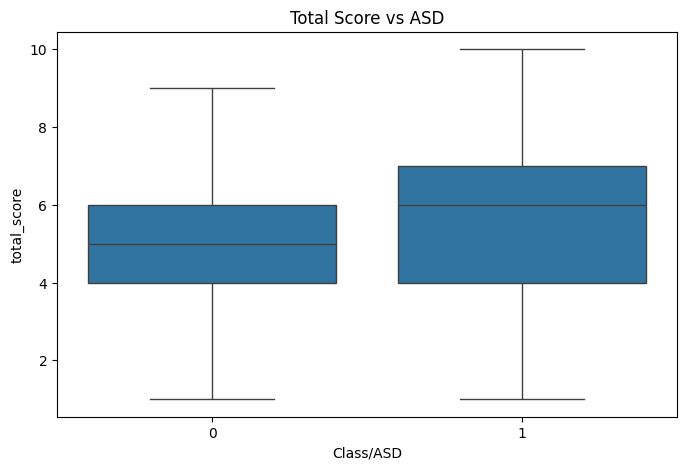

In [ ]:
# =========================================================
# AGE DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

sns.histplot(df['age'], kde=True)

plt.title("Age Distribution")

plt.show()

# =========================================================
# TOTAL SCORE DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

sns.histplot(df['total_score'], kde=True)

plt.title("Total Score Distribution")

plt.show()

# =========================================================
# ASD DISTRIBUTION
# =========================================================

plt.figure(figsize=(6,4))

sns.countplot(x='Class/ASD', data=df)

plt.title("ASD Distribution")

plt.show()

# =========================================================
# BOXPLOT
# =========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Class/ASD',
    y='total_score',
    data=df
)

plt.title("Total Score vs ASD")

plt.show()

In [ ]:
# =========================================================
# REMOVE NULL TARGETS
# =========================================================

df = df.dropna(subset=['Class/ASD']).copy()

# =========================================================
# CONVERT CATEGORICAL VARIABLES
# =========================================================

X = pd.get_dummies(
    df.drop(columns=['Class/ASD']),
    drop_first=True
)

# =========================================================
# TARGET VARIABLE
# =========================================================

y = df['Class/ASD'].map({
    'NO': 0,
    'YES': 1
})

print(X.head())

print(y.head())

   age  jaundice  austim  gender  A1_Score  A2_Score  A3_Score  A4_Score  \
0   43         1       1       1         0         0         1         1   
1   56         1       0       0         0         1         1         1   
2   33         0       0       0         0         0         1         1   
3   19         1       1       0         1         1         0         1   
4   47         0       1       0         0         0         1         1   

   A5_Score  A6_Score  A7_Score  A8_Score  A9_Score  A10_Score  total_score  
0         0         0         0         0         1          0            3  
1         0         0         1         1         0          0            5  
2         0         1         0         1         0          0            4  
3         0         1         1         0         0          0            5  
4         1         0         1         0         0          0            4  
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Class/ASD, dtype: float64


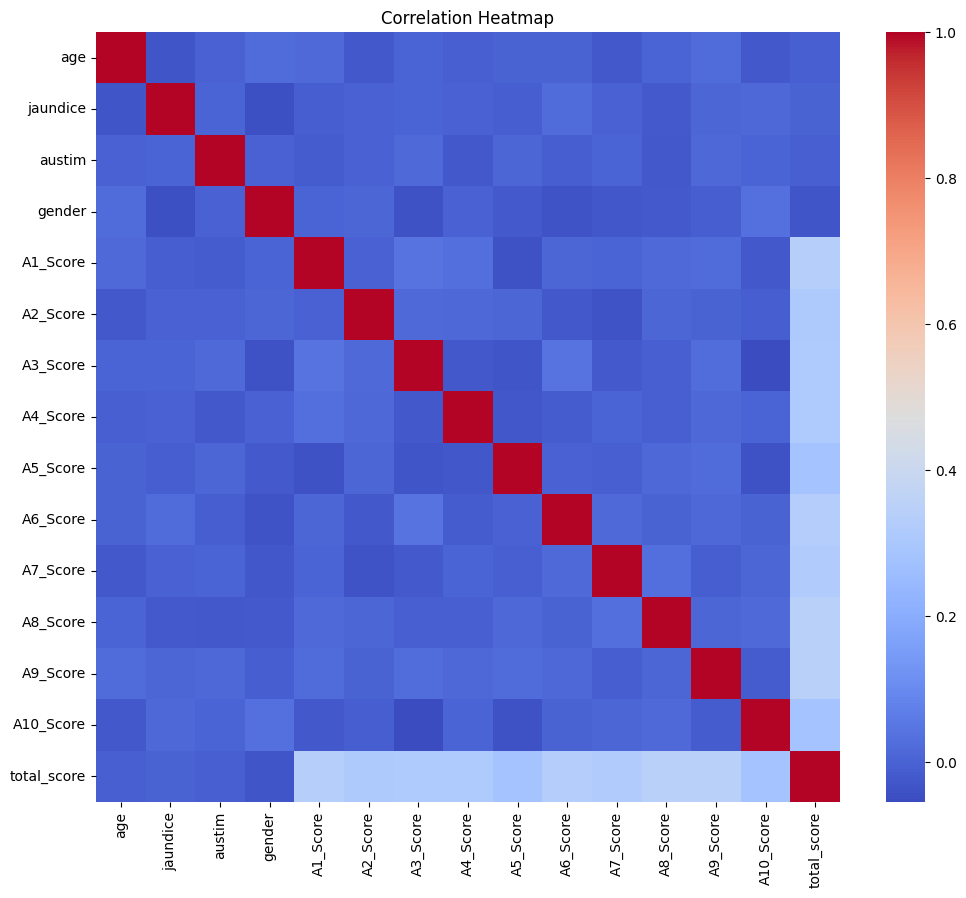

In [ ]:
# =========================================================
# CORRELATION HEATMAP
# =========================================================

plt.figure(figsize=(12,10))

sns.heatmap(
    X.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

y = df['Class/ASD'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)

print(X_test.shape)

print(X_train.shape)

print(X_test.shape)

(1600, 15)
(400, 15)
(1600, 15)
(400, 15)


In [ ]:
# =========================================================
# KNN
# =========================================================

knn = Pipeline([

    ("smote", SMOTE(random_state=42)),

    ("scaler", StandardScaler()),

    ("model", KNeighborsClassifier(
        n_neighbors=3,
        weights='distance',
        metric='manhattan'
    ))
])

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

print("KNN Accuracy:", knn_accuracy)

print(confusion_matrix(
    y_test,
    y_pred_knn
))

print(classification_report(
    y_test,
    y_pred_knn
))

KNN Accuracy: 0.82
[[196  42]
 [ 30 132]]
              precision    recall  f1-score   support

           0       0.87      0.82      0.84       238
           1       0.76      0.81      0.79       162

    accuracy                           0.82       400
   macro avg       0.81      0.82      0.82       400
weighted avg       0.82      0.82      0.82       400



In [ ]:
# =========================================================
# LOGISTIC REGRESSION
# =========================================================

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

print("Logistic Accuracy:", lr_accuracy)

print(confusion_matrix(
    y_test,
    y_pred_lr
))

print(classification_report(
    y_test,
    y_pred_lr
))

Logistic Accuracy: 0.7825
[[191  47]
 [ 40 122]]
              precision    recall  f1-score   support

           0       0.83      0.80      0.81       238
           1       0.72      0.75      0.74       162

    accuracy                           0.78       400
   macro avg       0.77      0.78      0.78       400
weighted avg       0.78      0.78      0.78       400



In [ ]:
# =========================================================
# RANDOM FOREST
# =========================================================

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("RF Accuracy:", rf_accuracy)

print(confusion_matrix(
    y_test,
    y_pred_rf
))

print(classification_report(
    y_test,
    y_pred_rf
))

RF Accuracy: 0.9225
[[228  10]
 [ 21 141]]
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       238
           1       0.93      0.87      0.90       162

    accuracy                           0.92       400
   macro avg       0.92      0.91      0.92       400
weighted avg       0.92      0.92      0.92       400



In [ ]:
# =========================================================
# XGBOOST PIPELINE
# =========================================================

pipeline = Pipeline([

    ("smote", SMOTE(random_state=42)),

    ("scaler", StandardScaler()),

    ("model", XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

# =========================================================
# PARAMETERS
# =========================================================

param_grid = {

    "model__n_estimators": [200, 300],

    "model__max_depth": [3, 5, 7],

    "model__learning_rate": [0.05, 0.1],
}

# =========================================================
# RANDOM SEARCH
# =========================================================

search = RandomizedSearchCV(

    pipeline,

    param_grid,

    n_iter=5,

    cv=5,

    scoring='accuracy',

    random_state=42
)

search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [200, 300]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.

In [ ]:
# =========================================================
# BEST MODEL
# =========================================================

best_model = search.best_estimator_

y_pred_xgb = best_model.predict(X_test)

xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

print("XGBoost Accuracy:", xgb_accuracy)

print(confusion_matrix(
    y_test,
    y_pred_xgb
))

print(classification_report(
    y_test,
    y_pred_xgb
))

XGBoost Accuracy: 0.925
[[228  10]
 [ 20 142]]
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       238
           1       0.93      0.88      0.90       162

    accuracy                           0.93       400
   macro avg       0.93      0.92      0.92       400
weighted avg       0.93      0.93      0.92       400



In [ ]:
# =========================================================
# DECISION TREE
# =========================================================

pipeline_dt = Pipeline([

    ('smote', SMOTE(random_state=42)),

    ('scaler', StandardScaler()),

    ('dt', DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

pipeline_dt.fit(X_train, y_train)

y_pred_dt = pipeline_dt.predict(X_test)

dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

print("Decision Tree Accuracy:", dt_accuracy)

print(confusion_matrix(
    y_test,
    y_pred_dt
))

print(classification_report(
    y_test,
    y_pred_dt
))

Decision Tree Accuracy: 0.9225
[[228  10]
 [ 21 141]]
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       238
           1       0.93      0.87      0.90       162

    accuracy                           0.92       400
   macro avg       0.92      0.91      0.92       400
weighted avg       0.92      0.92      0.92       400



In [ ]:
# =========================================================
# VOTING CLASSIFIER
# =========================================================

voting_model = VotingClassifier(

    estimators=[

        ('lr', lr),

        ('rf', rf),

        ('dt', pipeline_dt),

        ('knn', knn),

        ('xgb', best_model)

    ],

    voting='hard'
)

voting_model.fit(X_train, y_train)
pickle.dump(voting_model, open('autism_model.pkl', 'wb'))
y_pred_vote = voting_model.predict(X_test)

vote_accuracy = accuracy_score(
    y_test,
    y_pred_vote
)

print("Voting Accuracy:", vote_accuracy)

print(confusion_matrix(
    y_test,
    y_pred_vote
))

print(classification_report(
    y_test,
    y_pred_vote
))

NameError: name 'VotingClassifier' is not defined

In [ ]:
# =========================================================
# SAVE MODEL
# =========================================================

with open("mainmodel.pkl", "wb") as f:

    with open("mainmodel.pkl", "wb") as f:
        pickle.dump(voting_model, f)

    print("Model Saved Successfully!")

print("Model Saved Successfully!")

NameError: name 'pickle' is not defined

In [ ]:
# =========================================================
# RESULTS
# =========================================================

results = {

    'Logistic Regression': lr_accuracy,

    'Random Forest': rf_accuracy,

    'Decision Tree': dt_accuracy,

    'KNN': knn_accuracy,

    'XGBoost': xgb_accuracy,

    'Voting': vote_accuracy
}

print(results)

NameError: name 'lr_accuracy' is not defined

In [ ]:
# =========================================================
# BAR GRAPH
# =========================================================

models = list(results.keys())

accuracies = list(results.values())

plt.figure(figsize=(12,6))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

for i, v in enumerate(accuracies):

    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.ylim(0, 1.1)

plt.show()

NameError: name 'results' is not defined

In [ ]:
# =========================================================
# CONFUSION MATRIX DISPLAY
# =========================================================

ConfusionMatrixDisplay.from_estimator(
    voting_model,
    X_test,
    y_test
)

plt.title("Voting Classifier Confusion Matrix")

plt.show()

NameError: name 'ConfusionMatrixDisplay' is not defined

In [ ]:
import pickle

pickle.dump(voting_model, open("fresh_model.pkl", "wb"))


NameError: name 'voting_model' is not defined

In [ ]:
ls


 Volume in drive C is OS
 Volume Serial Number is 18D4-8C5A

 Directory of c:\Users\asus\Downloads\Aurtism

16-05-2026  21:30    <DIR>          .
16-05-2026  21:16    <DIR>          ..
16-05-2026  21:24    <DIR>          .venv
16-05-2026  20:22    <DIR>          backend
16-05-2026  20:32    <DIR>          Final Year Project
16-05-2026  21:33           290,271 Final.ipynb
16-05-2026  20:28    <DIR>          frontend
16-05-2026  20:32            65,957 good_autism_dataset_2000.csv
               2 File(s)        356,228 bytes
               6 Dir(s)  213,346,459,648 bytes free
